In [1]:
import pandas as pd
import numpy as np
from biom import load_table
from sklearn.decomposition import PCA, SparsePCA, IncrementalPCA
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, SubsetRandomSampler
from torch import optim
from TRPCA import trpca, utils
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm.notebook import tqdm
import gc
from scipy.stats import ttest_ind
from itertools import combinations

In [2]:
table = load_table('data/16S_feature-table.biom').to_dataframe(dense=True).T.astype(int)
age_metadata = pd.read_csv('data/thdmi-metadata.txt', sep='\t', index_col=0)

/var/folders/y9/wgj9mj_1555fbmw9d5qfq36m0000gn/T/ipykernel_15849/936811850.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  age_metadata = pd.read_csv('data/thdmi-metadata.txt', sep='\t', index_col=0)


In [3]:
age_metadata = age_metadata.loc[age_metadata.host_age.notna()&(age_metadata.host_age!='Unspecified')].drop_duplicates(subset='host_subject_id', keep='first')
table = table.loc[table.index.isin(age_metadata.index)]
age_metadata = age_metadata.loc[table.index]

In [4]:
columns_to_drop = table.columns[table.apply(lambda col: (col != 0).sum()) < 25] #drop columns with low prev
df1 = table.drop(columns=columns_to_drop)
df1 = np.log(df1+1)
print('CLR Transformed.')

CLR Transformed.


In [5]:
n_dimensions = 256
# # # # # # Preprocess with PCA (Re-using the PCA application code from earlier)
X1_reduced, pca1 = utils.apply_pca(df1, n_dimensions) 
df = pd.DataFrame(X1_reduced, index=df1.index)

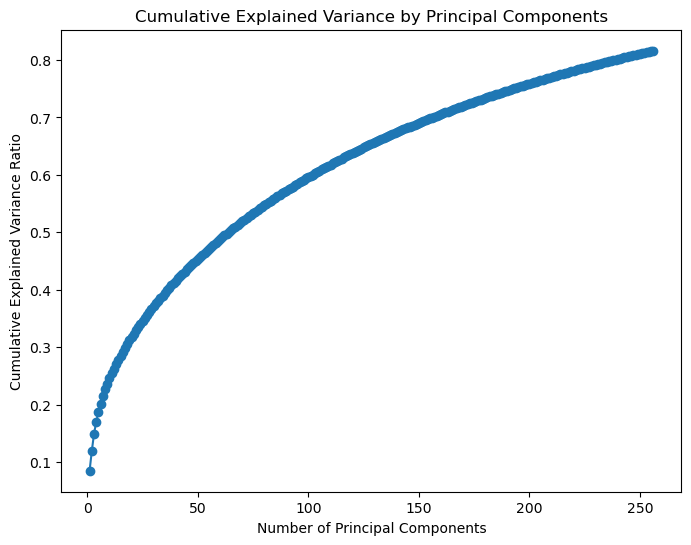

In [6]:
cum_explained_variance_ratio = np.cumsum(pca1.explained_variance_ratio_)

# Create a plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cum_explained_variance_ratio) + 1), cum_explained_variance_ratio, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance by Principal Components')
plt.show()

In [7]:
df['age'] = age_metadata.loc[age_metadata.index.isin(df.index)].host_age
df = df.loc[df.age.notna()]

In [8]:
age_metadata = age_metadata.loc[df.index]

In [9]:
# Parameters
num_folds = 5
batch_size = 512
epochs = 2000

# K-Fold Cross-Validator
# kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Prepare full dataset (no split into train/test yet)
X = torch.tensor(df.drop(columns=['age']).to_numpy(), dtype=torch.float32)
y = torch.tensor(df.age.astype(float).to_numpy(), dtype=torch.float32).unsqueeze(1)

dataset = TensorDataset(X, y)
# stratify_key = age_metadata.sex.fillna('male').astype(str)+'_'+age_metadata.cohort.astype(str)

original_indices = age_metadata.index.tolist()
# Loss function, model instantiation, etc., outside the loop
criterion = nn.L1Loss()

# Dictionary to store the test indices and their corresponding predictions and true values
test_predictions = {}
fold_performance = []
# Cross-validation starts add y=y for kf split
for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
    print(f'Fold {fold+1}/{num_folds}')
    train_subsampler = SubsetRandomSampler(train_idx)
    val_subsampler = SubsetRandomSampler(val_idx)

    # Create DataLoader for the current training and validation set
    train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_subsampler)
    val_loader = DataLoader(dataset, batch_size=batch_size, sampler=val_subsampler)

    # Reinitialize the model for each fold
    regression_model = trpca.TransformerRegressionModel(feature_size=n_dimensions, num_transformer_layers=3, nhead=8, dim_feedforward=2048, dropout=0.1, fast_transformer=True)
    optimizer = optim.SGD(regression_model.parameters(), lr=0.003)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=0)
    device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
    regression_model.to(device)

    best_valid_loss = float('inf')  # Initialize the best validation loss for the fold
    best_train_loss_at_best_val = None  # Track training loss when best validation loss occurs

    # Training and validation loop
    for epoch in tqdm(range(epochs), total=len(range(epochs))):
        # Training Phase
        regression_model.train()
        train_loss = 0
        for batch_features, batch_labels in train_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            optimizer.zero_grad()
            outputs = regression_model(batch_features)
            loss = criterion(outputs['regression_output'], batch_labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_features.size(0)

        train_loss /= len(train_idx)

        # Validation Phase
        regression_model.eval()
        valid_loss = 0
        with torch.no_grad():
            for batch_features, batch_labels in val_loader:
                batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
                outputs = regression_model(batch_features)
                loss = criterion(outputs['regression_output'], batch_labels)
                valid_loss += loss.item() * batch_features.size(0)

        valid_loss /= len(val_idx)

        # Epoch ends
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {valid_loss:.4f}')
        scheduler.step()
        # At the end of each epoch, evaluate on validation set
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_train_loss_at_best_val = train_loss

            # Save predictions for this fold
            all_preds = []
            all_y_true = []
            with torch.no_grad():
                for batch_features, batch_labels in val_loader:
                    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
                    outputs = regression_model(batch_features)
                    all_preds.extend(outputs['regression_output'].cpu().numpy())
                    all_y_true.extend(batch_labels.cpu().numpy())

            # # Update test predictions dictionary
            # test_predictions.update({idx: (pred, true) for idx, pred, true in zip(val_idx, all_preds, all_y_true)})
            # Map the integer indices back to the original string indices
            original_val_indices = [original_indices[i] for i in val_idx]

            # Update test predictions dictionary using original indices
            test_predictions.update({orig_idx: (pred, true) for orig_idx, pred, true in zip(original_val_indices, all_preds, all_y_true)})

    # Store the best validation loss of this fold and its associated training loss
    fold_performance.append((best_train_loss_at_best_val, best_valid_loss))
    torch.mps.empty_cache()
    gc.collect()
# Finalize cross-validation
print("K-Fold Cross-Validation completed.")
print("Best training and validation losses for each fold:", fold_performance)

### Step 2: Plot the Predictions

# Extract the indices and predictions
indices = list(test_predictions.keys())
predictions = [test_predictions[idx][0] for idx in indices]
true_values = [test_predictions[idx][1] for idx in indices]

Fold 1/5


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 45.4466, Val Loss: 45.8694
Epoch 2/2000, Train Loss: 45.2909, Val Loss: 45.7152
Epoch 3/2000, Train Loss: 45.1339, Val Loss: 45.5632
Epoch 4/2000, Train Loss: 44.9802, Val Loss: 45.4177
Epoch 5/2000, Train Loss: 44.8358, Val Loss: 45.2846
Epoch 6/2000, Train Loss: 44.7039, Val Loss: 45.1731
Epoch 7/2000, Train Loss: 44.5979, Val Loss: 45.0890
Epoch 8/2000, Train Loss: 44.5174, Val Loss: 45.0359
Epoch 9/2000, Train Loss: 44.4672, Val Loss: 45.0104
Epoch 10/2000, Train Loss: 44.4503, Val Loss: 45.0038
Epoch 11/2000, Train Loss: 44.3830, Val Loss: 44.6999
Epoch 12/2000, Train Loss: 44.0577, Val Loss: 44.3016
Epoch 13/2000, Train Loss: 43.6122, Val Loss: 43.7453
Epoch 14/2000, Train Loss: 43.0113, Val Loss: 42.9421
Epoch 15/2000, Train Loss: 42.1115, Val Loss: 41.7208
Epoch 16/2000, Train Loss: 40.7396, Val Loss: 39.8018
Epoch 17/2000, Train Loss: 38.6119, Val Loss: 36.7544
Epoch 18/2000, Train Loss: 35.1684, Val Loss: 31.8088
Epoch 19/2000, Train Loss: 29.6318, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 45.5328, Val Loss: 45.8836
Epoch 2/2000, Train Loss: 45.3897, Val Loss: 45.7373
Epoch 3/2000, Train Loss: 45.2472, Val Loss: 45.5952
Epoch 4/2000, Train Loss: 45.1085, Val Loss: 45.4610
Epoch 5/2000, Train Loss: 44.9735, Val Loss: 45.3410
Epoch 6/2000, Train Loss: 44.8638, Val Loss: 45.2423
Epoch 7/2000, Train Loss: 44.7677, Val Loss: 45.1685
Epoch 8/2000, Train Loss: 44.7014, Val Loss: 45.1223
Epoch 9/2000, Train Loss: 44.6604, Val Loss: 45.1002
Epoch 10/2000, Train Loss: 44.6423, Val Loss: 45.0945
Epoch 11/2000, Train Loss: 44.5818, Val Loss: 44.8388
Epoch 12/2000, Train Loss: 44.3193, Val Loss: 44.5152
Epoch 13/2000, Train Loss: 43.9823, Val Loss: 44.0825
Epoch 14/2000, Train Loss: 43.5171, Val Loss: 43.4866
Epoch 15/2000, Train Loss: 42.8859, Val Loss: 42.6273
Epoch 16/2000, Train Loss: 41.9509, Val Loss: 41.3542
Epoch 17/2000, Train Loss: 40.5568, Val Loss: 39.4291
Epoch 18/2000, Train Loss: 38.4561, Val Loss: 36.5032
Epoch 19/2000, Train Loss: 35.2841, V

...

Epoch 1/2000, Train Loss: 45.6867, Val Loss: 45.1414
Epoch 2/2000, Train Loss: 45.5283, Val Loss: 44.9869
Epoch 3/2000, Train Loss: 45.3779, Val Loss: 44.8356
Epoch 4/2000, Train Loss: 45.2257, Val Loss: 44.6914
Epoch 5/2000, Train Loss: 45.0858, Val Loss: 44.5613
Epoch 6/2000, Train Loss: 44.9580, Val Loss: 44.4500
Epoch 7/2000, Train Loss: 44.8540, Val Loss: 44.3673
Epoch 8/2000, Train Loss: 44.7778, Val Loss: 44.3144
Epoch 9/2000, Train Loss: 44.7245, Val Loss: 44.2891
Epoch 10/2000, Train Loss: 44.7067, Val Loss: 44.2825
Epoch 11/2000, Train Loss: 44.6434, Val Loss: 43.9826
Epoch 12/2000, Train Loss: 44.3208, Val Loss: 43.5842
Epoch 13/2000, Train Loss: 43.8840, Val Loss: 43.0199
Epoch 14/2000, Train Loss: 43.2738, Val Loss: 42.1911
Epoch 15/2000, Train Loss: 42.3651, Val Loss: 40.9372
Epoch 16/2000, Train Loss: 40.9818, Val Loss: 38.9690
Epoch 17/2000, Train Loss: 38.8158, Val Loss: 35.8409
Epoch 18/2000, Train Loss: 35.3327, Val Loss: 30.7505
Epoch 19/2000, Train Loss: 29.7331, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 45.7074, Val Loss: 45.5576
Epoch 2/2000, Train Loss: 45.5703, Val Loss: 45.4145
Epoch 3/2000, Train Loss: 45.4279, Val Loss: 45.2758
Epoch 4/2000, Train Loss: 45.2941, Val Loss: 45.1454
Epoch 5/2000, Train Loss: 45.1694, Val Loss: 45.0287
Epoch 6/2000, Train Loss: 45.0572, Val Loss: 44.9321
Epoch 7/2000, Train Loss: 44.9700, Val Loss: 44.8613
Epoch 8/2000, Train Loss: 44.9056, Val Loss: 44.8171
Epoch 9/2000, Train Loss: 44.8642, Val Loss: 44.7958
Epoch 10/2000, Train Loss: 44.8468, Val Loss: 44.7903
Epoch 11/2000, Train Loss: 44.7958, Val Loss: 44.5453
Epoch 12/2000, Train Loss: 44.5418, Val Loss: 44.2396
Epoch 13/2000, Train Loss: 44.2239, Val Loss: 43.8406
Epoch 14/2000, Train Loss: 43.8061, Val Loss: 43.3007
Epoch 15/2000, Train Loss: 43.2389, Val Loss: 42.5407
Epoch 16/2000, Train Loss: 42.4246, Val Loss: 41.4404
Epoch 17/2000, Train Loss: 41.2262, Val Loss: 39.8117
Epoch 18/2000, Train Loss: 39.5006, Val Loss: 37.4127
Epoch 19/2000, Train Loss: 36.9051, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 45.8481, Val Loss: 45.1810
Epoch 2/2000, Train Loss: 45.6954, Val Loss: 45.0269
Epoch 3/2000, Train Loss: 45.5390, Val Loss: 44.8730
Epoch 4/2000, Train Loss: 45.3840, Val Loss: 44.7244
Epoch 5/2000, Train Loss: 45.2359, Val Loss: 44.5878
Epoch 6/2000, Train Loss: 45.1020, Val Loss: 44.4722
Epoch 7/2000, Train Loss: 44.9887, Val Loss: 44.3850
Epoch 8/2000, Train Loss: 44.9067, Val Loss: 44.3291
Epoch 9/2000, Train Loss: 44.8540, Val Loss: 44.3025
Epoch 10/2000, Train Loss: 44.8336, Val Loss: 44.2954
Epoch 11/2000, Train Loss: 44.7616, Val Loss: 43.9762
Epoch 12/2000, Train Loss: 44.4174, Val Loss: 43.5434
Epoch 13/2000, Train Loss: 43.9393, Val Loss: 42.9346
Epoch 14/2000, Train Loss: 43.2691, Val Loss: 42.0325
Epoch 15/2000, Train Loss: 42.2734, Val Loss: 40.6620
Epoch 16/2000, Train Loss: 40.7556, Val Loss: 38.4849
Epoch 17/2000, Train Loss: 38.3481, Val Loss: 34.9660
Epoch 18/2000, Train Loss: 34.4420, Val Loss: 29.1736
Epoch 19/2000, Train Loss: 28.0756, V

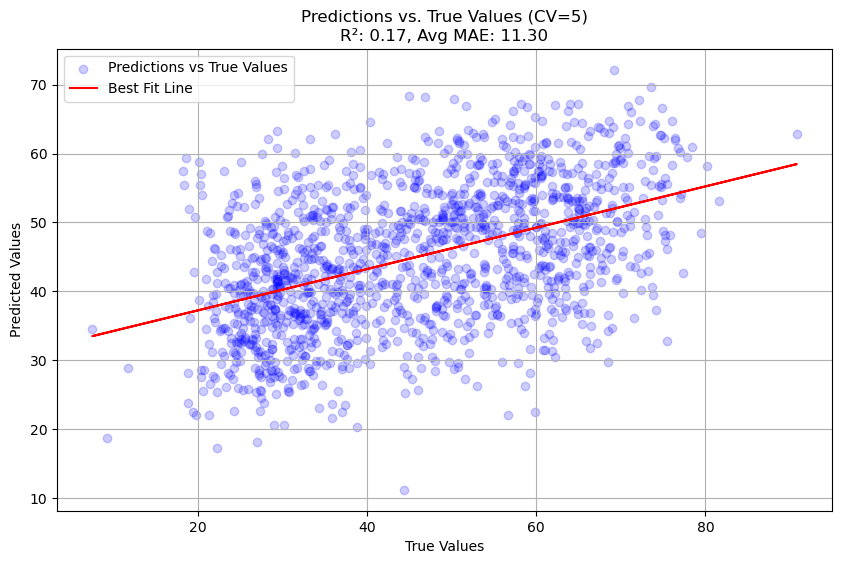

In [10]:
predictions = np.array(predictions)
true_values = np.array(true_values)

# Calculate R² and MAE
r2 = r2_score(true_values, predictions)
mae = mean_absolute_error(true_values, predictions)

# Calculate coefficients for the best fit line
slope, intercept = np.polyfit(true_values.reshape(-1), predictions.reshape(-1), 1)
best_fit_line = slope * true_values + intercept

plt.figure(figsize=(10, 6))
plt.scatter(true_values, predictions, color='blue', alpha=0.2, label='Predictions vs True Values')
plt.plot(true_values, best_fit_line, color='red', label='Best Fit Line')  # Plotting the best fit line
plt.title(f'Predictions vs. True Values (CV=5)\nR²: {r2:.2f}, Avg MAE: {mae:.2f}')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)  # Optional: Adds grid for better visualization
plt.show()

### WGS age regression on paired samples. 

In [11]:
table = load_table('data/per_genome_feature-table.biom').to_dataframe(dense=True).T.astype(int)
table = table.loc[table.index.isin(age_metadata.index)]

In [12]:
columns_to_drop = table.columns[table.apply(lambda col: (col != 0).sum()) < 0] #drop columns with low prev
df1 = table.drop(columns=columns_to_drop)
df1 = np.log(df1+1)
print('CLR Transformed.')

CLR Transformed.


In [13]:
n_dimensions = 256
# # # # # # Preprocess with PCA (Re-using the PCA application code from earlier)
X1_reduced, pca1 = utils.apply_pca(df1, n_dimensions) 
df = pd.DataFrame(X1_reduced, index=df1.index)

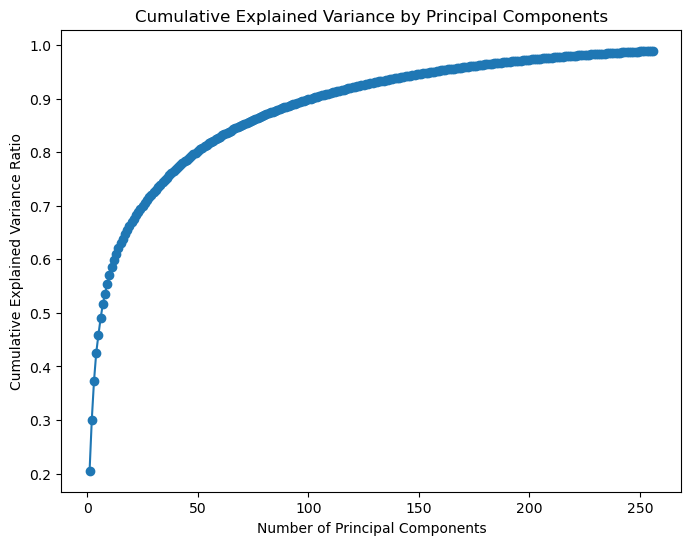

In [14]:
cum_explained_variance_ratio = np.cumsum(pca1.explained_variance_ratio_)

# Create a plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cum_explained_variance_ratio) + 1), cum_explained_variance_ratio, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance by Principal Components')
plt.show()

In [15]:
df['age'] = age_metadata.loc[age_metadata.index.isin(df.index)].host_age
df = df.loc[df.age.notna()]

In [16]:
age_metadata = age_metadata.loc[df.index]

In [17]:
# Parameters
num_folds = 5
batch_size = 512
epochs = 2000

# K-Fold Cross-Validator
# kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Prepare full dataset (no split into train/test yet)
X = torch.tensor(df.drop(columns=['age']).to_numpy(), dtype=torch.float32)
y = torch.tensor(df.age.astype(float).to_numpy(), dtype=torch.float32).unsqueeze(1)

dataset = TensorDataset(X, y)
# stratify_key = age_metadata.sex.fillna('male').astype(str)+'_'+age_metadata.cohort.astype(str)

original_indices = age_metadata.index.tolist()
# Loss function, model instantiation, etc., outside the loop
criterion = nn.L1Loss()

# Dictionary to store the test indices and their corresponding predictions and true values
test_predictions = {}
fold_performance = []
# Cross-validation starts add y=y for kf split
for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
    print(f'Fold {fold+1}/{num_folds}')
    train_subsampler = SubsetRandomSampler(train_idx)
    val_subsampler = SubsetRandomSampler(val_idx)

    # Create DataLoader for the current training and validation set
    train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_subsampler)
    val_loader = DataLoader(dataset, batch_size=batch_size, sampler=val_subsampler)

    # Reinitialize the model for each fold
    regression_model = trpca.TransformerRegressionModel(feature_size=n_dimensions, num_transformer_layers=3, nhead=8, dim_feedforward=2048, dropout=0.1, fast_transformer=True)
    optimizer = optim.SGD(regression_model.parameters(), lr=0.003)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=0)
    device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
    regression_model.to(device)

    best_valid_loss = float('inf')  # Initialize the best validation loss for the fold
    best_train_loss_at_best_val = None  # Track training loss when best validation loss occurs

    # Training and validation loop
    for epoch in tqdm(range(epochs), total=len(range(epochs))):
        # Training Phase
        regression_model.train()
        train_loss = 0
        for batch_features, batch_labels in train_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            optimizer.zero_grad()
            outputs = regression_model(batch_features)
            loss = criterion(outputs['regression_output'], batch_labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_features.size(0)

        train_loss /= len(train_idx)

        # Validation Phase
        regression_model.eval()
        valid_loss = 0
        with torch.no_grad():
            for batch_features, batch_labels in val_loader:
                batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
                outputs = regression_model(batch_features)
                loss = criterion(outputs['regression_output'], batch_labels)
                valid_loss += loss.item() * batch_features.size(0)

        valid_loss /= len(val_idx)

        # Epoch ends
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {valid_loss:.4f}')
        scheduler.step()
        # At the end of each epoch, evaluate on validation set
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_train_loss_at_best_val = train_loss

            # Save predictions for this fold
            all_preds = []
            all_y_true = []
            with torch.no_grad():
                for batch_features, batch_labels in val_loader:
                    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
                    outputs = regression_model(batch_features)
                    all_preds.extend(outputs['regression_output'].cpu().numpy())
                    all_y_true.extend(batch_labels.cpu().numpy())

            # # Update test predictions dictionary
            # test_predictions.update({idx: (pred, true) for idx, pred, true in zip(val_idx, all_preds, all_y_true)})
            # Map the integer indices back to the original string indices
            original_val_indices = [original_indices[i] for i in val_idx]

            # Update test predictions dictionary using original indices
            test_predictions.update({orig_idx: (pred, true) for orig_idx, pred, true in zip(original_val_indices, all_preds, all_y_true)})

    # Store the best validation loss of this fold and its associated training loss
    fold_performance.append((best_train_loss_at_best_val, best_valid_loss))
    torch.mps.empty_cache()
    gc.collect()
# Finalize cross-validation
print("K-Fold Cross-Validation completed.")
print("Best training and validation losses for each fold:", fold_performance)

### Step 2: Plot the Predictions

# Extract the indices and predictions
indices = list(test_predictions.keys())
predictions = [test_predictions[idx][0] for idx in indices]
true_values = [test_predictions[idx][1] for idx in indices]

Fold 1/5


  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 45.6389, Val Loss: 45.8745
Epoch 2/2000, Train Loss: 45.4761, Val Loss: 45.7110
Epoch 3/2000, Train Loss: 45.3093, Val Loss: 45.5484
Epoch 4/2000, Train Loss: 45.1511, Val Loss: 45.3928
Epoch 5/2000, Train Loss: 44.9973, Val Loss: 45.2452
Epoch 6/2000, Train Loss: 44.8553, Val Loss: 45.1202
Epoch 7/2000, Train Loss: 44.7351, Val Loss: 45.0255
Epoch 8/2000, Train Loss: 44.6471, Val Loss: 44.9648
Epoch 9/2000, Train Loss: 44.6027, Val Loss: 44.9353
Epoch 10/2000, Train Loss: 44.5682, Val Loss: 44.9277
Epoch 11/2000, Train Loss: 44.4834, Val Loss: 44.5718
Epoch 12/2000, Train Loss: 44.1190, Val Loss: 44.0971
Epoch 13/2000, Train Loss: 43.5919, Val Loss: 43.3828
Epoch 14/2000, Train Loss: 42.8185, Val Loss: 42.2636
Epoch 15/2000, Train Loss: 41.6454, Val Loss: 40.5871
Epoch 16/2000, Train Loss: 39.7319, Val Loss: 37.7631
Epoch 17/2000, Train Loss: 36.6236, Val Loss: 32.9887
Epoch 18/2000, Train Loss: 31.2769, Val Loss: 24.8030
Epoch 19/2000, Train Loss: 22.4118, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 45.8285, Val Loss: 44.6985
Epoch 2/2000, Train Loss: 45.6683, Val Loss: 44.5318
Epoch 3/2000, Train Loss: 45.4972, Val Loss: 44.3676
Epoch 4/2000, Train Loss: 45.3298, Val Loss: 44.2020
Epoch 5/2000, Train Loss: 45.1629, Val Loss: 44.0481
Epoch 6/2000, Train Loss: 45.0121, Val Loss: 43.9128
Epoch 7/2000, Train Loss: 44.8797, Val Loss: 43.8127
Epoch 8/2000, Train Loss: 44.7818, Val Loss: 43.7416
Epoch 9/2000, Train Loss: 44.7223, Val Loss: 43.7102
Epoch 10/2000, Train Loss: 44.6947, Val Loss: 43.7017
Epoch 11/2000, Train Loss: 44.6189, Val Loss: 43.3112
Epoch 12/2000, Train Loss: 44.1814, Val Loss: 42.7387
Epoch 13/2000, Train Loss: 43.5602, Val Loss: 41.8835
Epoch 14/2000, Train Loss: 42.6209, Val Loss: 40.4845
Epoch 15/2000, Train Loss: 41.0952, Val Loss: 38.1461
Epoch 16/2000, Train Loss: 38.5170, Val Loss: 34.1902
Epoch 17/2000, Train Loss: 34.1516, Val Loss: 27.1875
Epoch 18/2000, Train Loss: 26.1562, Val Loss: 16.1358
Epoch 19/2000, Train Loss: 16.3792, V

...

Epoch 1/2000, Train Loss: 45.4878, Val Loss: 46.6221
Epoch 2/2000, Train Loss: 45.3323, Val Loss: 46.4709
Epoch 3/2000, Train Loss: 45.1789, Val Loss: 46.3276
Epoch 4/2000, Train Loss: 45.0422, Val Loss: 46.1912
Epoch 5/2000, Train Loss: 44.9101, Val Loss: 46.0720
Epoch 6/2000, Train Loss: 44.7970, Val Loss: 45.9741
Epoch 7/2000, Train Loss: 44.7033, Val Loss: 45.9013
Epoch 8/2000, Train Loss: 44.6376, Val Loss: 45.8559
Epoch 9/2000, Train Loss: 44.5959, Val Loss: 45.8341
Epoch 10/2000, Train Loss: 44.5799, Val Loss: 45.8284
Epoch 11/2000, Train Loss: 44.5239, Val Loss: 45.5732
Epoch 12/2000, Train Loss: 44.2555, Val Loss: 45.2482
Epoch 13/2000, Train Loss: 43.9111, Val Loss: 44.8019
Epoch 14/2000, Train Loss: 43.4503, Val Loss: 44.1774
Epoch 15/2000, Train Loss: 42.7950, Val Loss: 43.2453
Epoch 16/2000, Train Loss: 41.8166, Val Loss: 41.8465
Epoch 17/2000, Train Loss: 40.3096, Val Loss: 39.6944
Epoch 18/2000, Train Loss: 37.9871, Val Loss: 36.3920
Epoch 19/2000, Train Loss: 34.4127, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 45.7219, Val Loss: 45.2730
Epoch 2/2000, Train Loss: 45.5641, Val Loss: 45.1094
Epoch 3/2000, Train Loss: 45.4034, Val Loss: 44.9441
Epoch 4/2000, Train Loss: 45.2419, Val Loss: 44.7859
Epoch 5/2000, Train Loss: 45.0916, Val Loss: 44.6418
Epoch 6/2000, Train Loss: 44.9550, Val Loss: 44.5195
Epoch 7/2000, Train Loss: 44.8332, Val Loss: 44.4248
Epoch 8/2000, Train Loss: 44.7479, Val Loss: 44.3651
Epoch 9/2000, Train Loss: 44.6940, Val Loss: 44.3364
Epoch 10/2000, Train Loss: 44.6836, Val Loss: 44.3292
Epoch 11/2000, Train Loss: 44.6090, Val Loss: 43.9975
Epoch 12/2000, Train Loss: 44.2605, Val Loss: 43.5386
Epoch 13/2000, Train Loss: 43.7530, Val Loss: 42.8785
Epoch 14/2000, Train Loss: 43.0425, Val Loss: 41.9001
Epoch 15/2000, Train Loss: 41.9345, Val Loss: 40.3530
Epoch 16/2000, Train Loss: 40.2817, Val Loss: 37.8674
Epoch 17/2000, Train Loss: 37.5141, Val Loss: 33.7768
Epoch 18/2000, Train Loss: 32.8910, Val Loss: 26.9233
Epoch 19/2000, Train Loss: 25.3340, V

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/2000, Train Loss: 45.7193, Val Loss: 45.3115
Epoch 2/2000, Train Loss: 45.5577, Val Loss: 45.1404
Epoch 3/2000, Train Loss: 45.3887, Val Loss: 44.9687
Epoch 4/2000, Train Loss: 45.2132, Val Loss: 44.7961
Epoch 5/2000, Train Loss: 45.0433, Val Loss: 44.6360
Epoch 6/2000, Train Loss: 44.8859, Val Loss: 44.4979
Epoch 7/2000, Train Loss: 44.7519, Val Loss: 44.3912
Epoch 8/2000, Train Loss: 44.6637, Val Loss: 44.3243
Epoch 9/2000, Train Loss: 44.5976, Val Loss: 44.2909
Epoch 10/2000, Train Loss: 44.5691, Val Loss: 44.2821
Epoch 11/2000, Train Loss: 44.4836, Val Loss: 43.8801
Epoch 12/2000, Train Loss: 44.0554, Val Loss: 43.3084
Epoch 13/2000, Train Loss: 43.4124, Val Loss: 42.4366
Epoch 14/2000, Train Loss: 42.4965, Val Loss: 41.1248
Epoch 15/2000, Train Loss: 41.0228, Val Loss: 38.9414
Epoch 16/2000, Train Loss: 38.5738, Val Loss: 35.3020
Epoch 17/2000, Train Loss: 34.4807, Val Loss: 28.9008
Epoch 18/2000, Train Loss: 27.3104, Val Loss: 18.7020
Epoch 19/2000, Train Loss: 17.6100, V

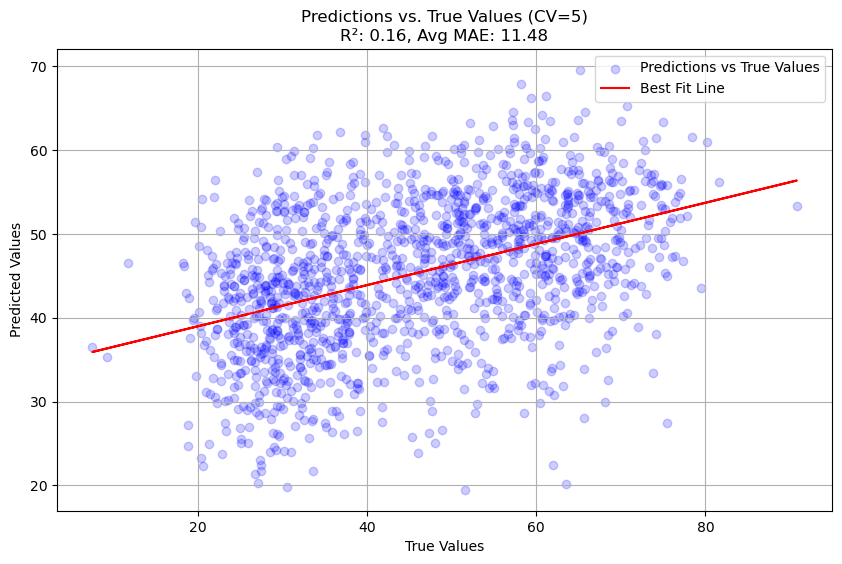

In [18]:
predictions = np.array(predictions)
true_values = np.array(true_values)

# Calculate R² and MAE
r2 = r2_score(true_values, predictions)
mae = mean_absolute_error(true_values, predictions)

# Calculate coefficients for the best fit line
slope, intercept = np.polyfit(true_values.reshape(-1), predictions.reshape(-1), 1)
best_fit_line = slope * true_values + intercept

plt.figure(figsize=(10, 6))
plt.scatter(true_values, predictions, color='blue', alpha=0.2, label='Predictions vs True Values')
plt.plot(true_values, best_fit_line, color='red', label='Best Fit Line')  # Plotting the best fit line
plt.title(f'Predictions vs. True Values (CV=5)\nR²: {r2:.2f}, Avg MAE: {mae:.2f}')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)  # Optional: Adds grid for better visualization
plt.show()